In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from feature_engine.imputation import MeanMedianImputer
from feature_engine.selection import DropConstantFeatures, SmartCorrelatedSelection, DropDuplicateFeatures
from feature_engine.outliers import Winsorizer
from feature_engine.transformation import YeoJohnsonTransformer
from sklearn.preprocessing import StandardScaler
import os

from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, Descriptors, AllChem


import warnings
warnings.filterwarnings('ignore')

# Suppress TensorFlow logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# I. Training Dataset:

In [32]:
df_train = pd.read_csv('./3-DNN_Baseline/V2-merged_df_noOutliers.csv')
df_train.head(2)

,cid,Smiles,Standard Value,pIC50 Value,nAcid,ALogP,ALogp2,AMR,apol,naAromAtom,...,3d-P2s,3d-E1s,3d-E2s,3d-E3s,3d-Ts,3d-As,3d-Vs,3d-Ks,3d-Ds,QT-pIC50 Value
0,23647975,COc1cc(cc(Cc2cnc(N)nc2N)c1OC)C#CCCCC(O)=O,34.0,7.468521,1,-0.9874,0.974959,55.7857,55.717446,12,...,0.270792,0.568703,0.404621,0.409698,22.863896,123.556813,272.29810,0.506905,1.383022,0.624900
1,5578,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,2722.0,5.565112,0,-1.1990,1.437601,34.9926,43.448274,12,...,0.223644,0.526743,0.420964,0.415681,15.650156,58.403017,129.62338,0.521793,1.363389,-0.538272


## 1. Elements in My training database:

In [33]:
import re
import pandas as pd

# Regular expression pattern to match atom elements in SMILES
atom_pattern = r'[A-Z][a-z]?'

# Initialize an empty set to hold unique atom elements
atom_elements = set()

# Extract atom elements from each SMILES string
for smiles in df_train['Smiles']:
    if smiles:  # Check if the SMILES string is not None
        atoms = re.findall(atom_pattern, smiles)
        atom_elements.update(atoms)

# Convert the set to a list (if needed)
atom_elements_list_tg = list(atom_elements)

# Display the list of atom elements
print("List of atom elements in the dataset:", atom_elements_list_tg)


List of atom elements in the dataset: ['S', 'N', 'O', 'P', 'Oc', 'Br', 'I', 'H', 'Cl', 'F', 'Sc', 'C', 'Cc', 'Cn', 'B', 'Nc']


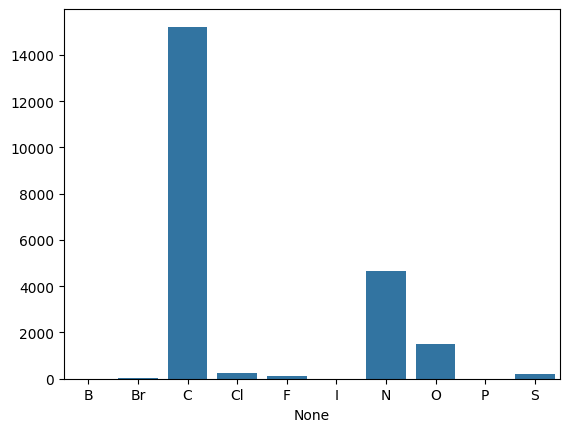

In [34]:
def atom_frequency(smiles_list):
    """
    frequency of different atom types in SMILES
    :param smiles_list: A list of SMILES strings
    """
    atom_counts = []
    for smiles in smiles_list:
        # Convert the SMILES string to an RDKit molecule object
        mol = Chem.MolFromSmiles(smiles)
        # Get the atoms in the molecule
        atoms = mol.GetAtoms()
        # Add the symbol for each atom to the atom_counts list
        atom_counts.extend([atom.GetSymbol() for atom in atoms])

    # Create a pandas series with the counts of each atom type
    plot_data = pd.Series(atom_counts).value_counts().sort_index()
    sns.barplot(x=plot_data.index, y=plot_data.values)

atom_frequency(df_train['Smiles'])

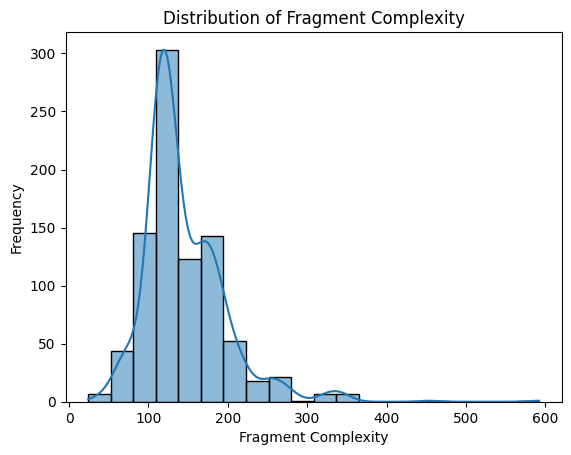

In [35]:
sns.histplot(data=df_train, x='fragC', bins=20, kde=True)
plt.title('Distribution of Fragment Complexity')
plt.xlabel('Fragment Complexity')
plt.ylabel('Frequency')
plt.show()

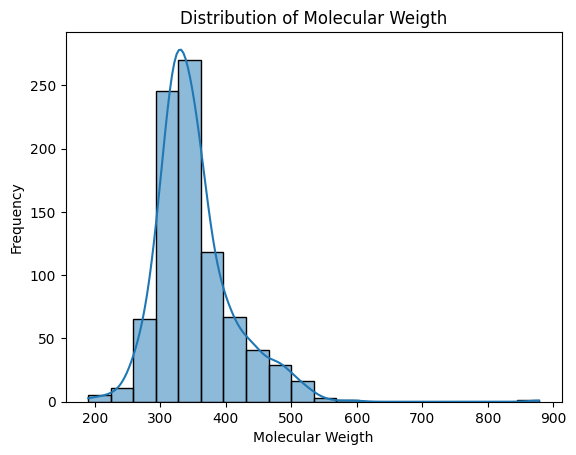

In [36]:
sns.histplot(data=df_train, x='MW', bins=20, kde=True)
plt.title('Distribution of Molecular Weigth')
plt.xlabel('Molecular Weigth')
plt.ylabel('Frequency')
plt.show()


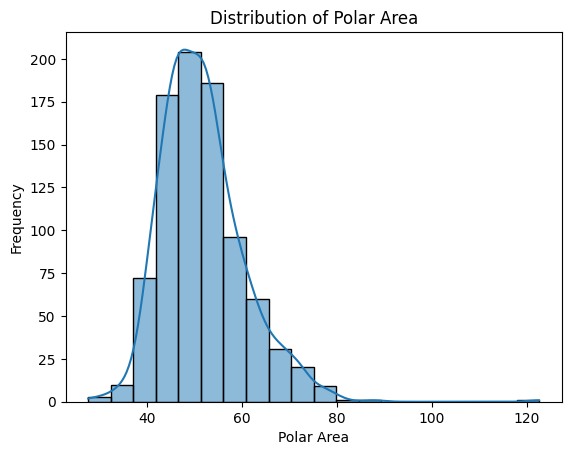

In [37]:
sns.histplot(data=df_train, x='apol', bins=20, kde=True)
plt.title('Distribution of Polar Area')
plt.xlabel('Polar Area')
plt.ylabel('Frequency')
plt.show()

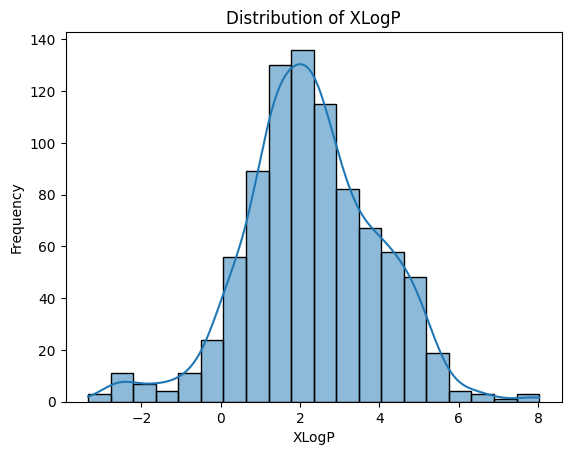

In [38]:
sns.histplot(data=df_train, x='XLogP', bins=20, kde=True)
plt.title('Distribution of XLogP')
plt.xlabel('XLogP')
plt.ylabel('Frequency')
plt.show()

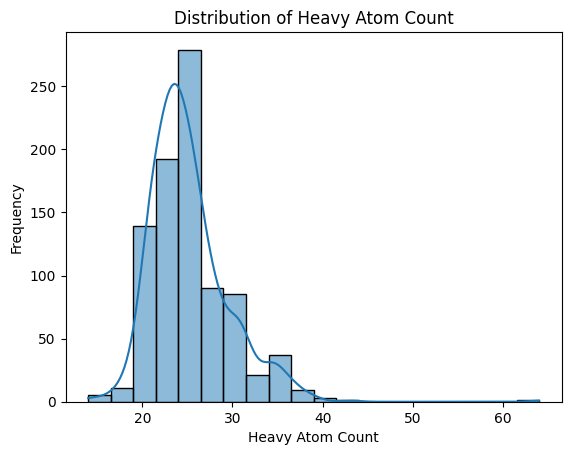

In [39]:
sns.histplot(data=df_train, x='nHeavyAtom', bins=20, kde=True)
plt.title('Distribution of Heavy Atom Count')
plt.xlabel('Heavy Atom Count')
plt.ylabel('Frequency')
plt.show()

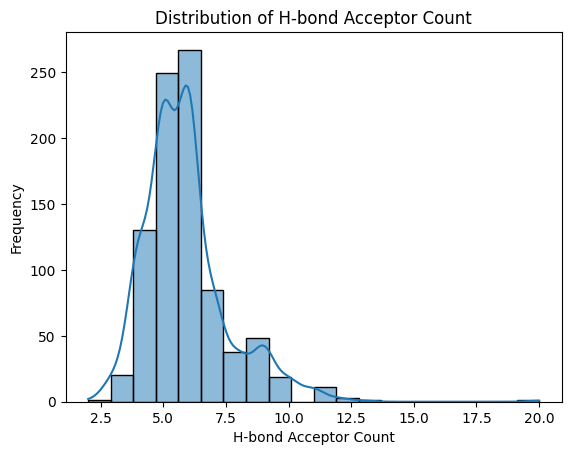

In [40]:
sns.histplot(data=df_train, x='nHBAcc', bins=20, kde=True)
plt.title('Distribution of H-bond Acceptor Count')
plt.xlabel('H-bond Acceptor Count')
plt.ylabel('Frequency')
plt.show()

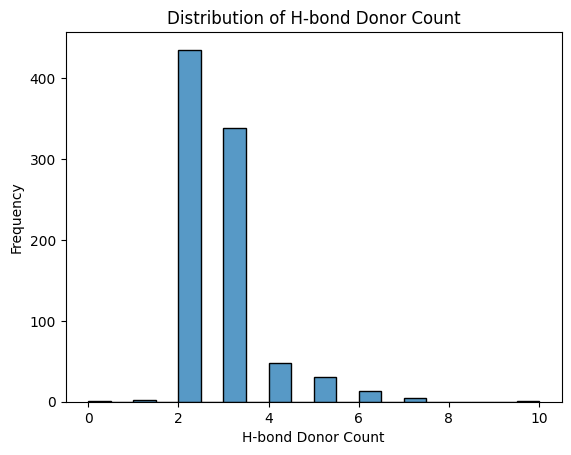

In [41]:
sns.histplot(data=df_train, x='nHBDon', bins=20, kde=False)
plt.title('Distribution of H-bond Donor Count')
plt.xlabel('H-bond Donor Count')
plt.ylabel('Frequency')
plt.show()

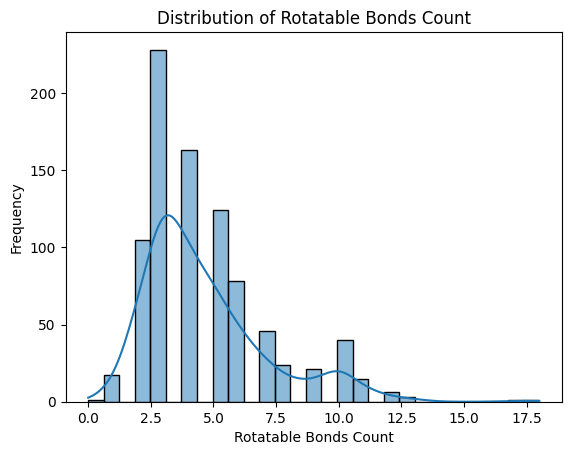

In [42]:
sns.histplot(data=df_train, x='nRotB', kde=True)
plt.title('Distribution of Rotatable Bonds Count')
plt.xlabel('Rotatable Bonds Count')
plt.ylabel('Frequency')
plt.show()

# II. FDA Dataset (PubChem):

In [43]:
df_fda = pd.read_csv('PubChem_FDA-approved_NoInorganics.csv')
df_fda.head(2)

,cid,cmpdname,cmpdsynonym,mw,mf,polararea,complexity,xlogp,heavycnt,hbonddonor,...,gpidcnt,gpfamilycnt,meshheadings,annothits,annothitcnt,aids,cidcdate,sidsrcname,depcatg,annotation
0,176,Acetic Acid,acetic acid|ethanoic acid|64-19-7|Acetic acid ...,60.05,C2H4O2,37.3,31.0,-0.2,4,1,...,288903,167925,Acetic Acid,Agrochemical Information|Biological Test Resul...,19,248|17814|17815|17816|17817|17818|17819|17820|...,20040916,001Chemical|10X CHEM|1st Scientific|3B Scienti...,Chemical Vendors|Curation Efforts|Governmental...,C254 - Anti-Infective Agent|D000890 - Anti-Inf...
1,244,Benzyl Alcohol,benzyl alcohol|phenylmethanol|benzenemethanol|...,108.14,C7H8O,20.2,55.4,1.1,8,1,...,430390,147130,Benzyl Alcohol,Biological Test Results|Interactions and Pathw...,18,155|157|161|165|167|175|192|248|328|330|421|42...,20040916,001Chemical|10X CHEM|3B Scientific (Wuhan) Cor...,Chemical Vendors|Curation Efforts|Governmental...,"P - Antiparasitic products, insecticides and r..."


In [44]:
df_fda.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3378 entries, 0 to 3377
Data columns (total 39 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0    cid                    3378 non-null   int64  
 1   cmpdname                3378 non-null   object 
 2   cmpdsynonym             3319 non-null   object 
 3   mw                      3378 non-null   float64
 4   mf                      3378 non-null   object 
 5   polararea               3378 non-null   float64
 6   complexity              3378 non-null   float64
 7   xlogp                   1683 non-null   float64
 8   heavycnt                3378 non-null   int64  
 9   hbonddonor              3378 non-null   int64  
 10  hbondacc                3378 non-null   int64  
 11  rotbonds                3378 non-null   int64  
 12  inchi                   3378 non-null   object 
 13  isosmiles               3378 non-null   object 
 14  canonicalsmiles         3378 non-null   

In [45]:
df_fda.shape

(3378, 39)

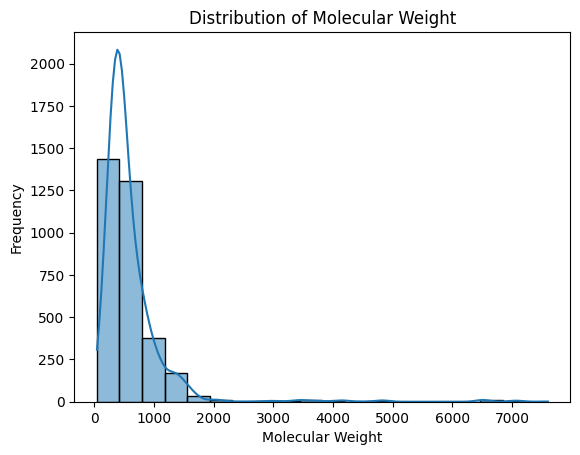

In [46]:
sns.histplot(data=df_fda, x='mw', bins=20, kde=True)
plt.title('Distribution of Molecular Weight')
plt.xlabel('Molecular Weight')
plt.ylabel('Frequency')
plt.show()

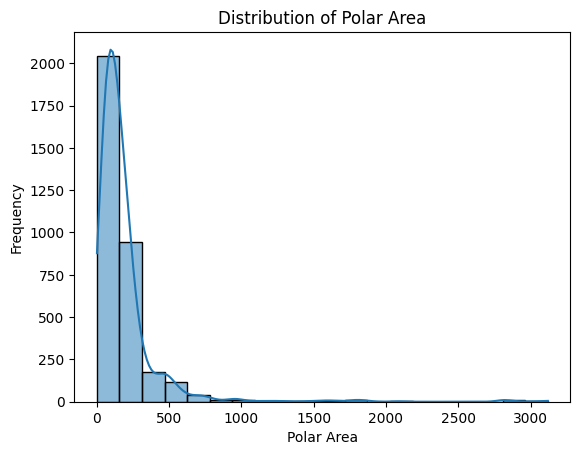

In [47]:
sns.histplot(data=df_fda, x='polararea', bins=20, kde=True)
plt.title('Distribution of Polar Area')
plt.xlabel('Polar Area')
plt.ylabel('Frequency')
plt.show()

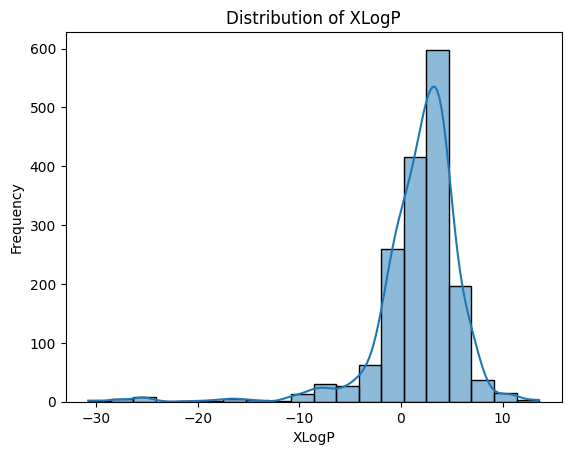

In [48]:
sns.histplot(data=df_fda, x='xlogp', bins=20, kde=True)
plt.title('Distribution of XLogP')
plt.xlabel('XLogP')
plt.ylabel('Frequency')
plt.show()

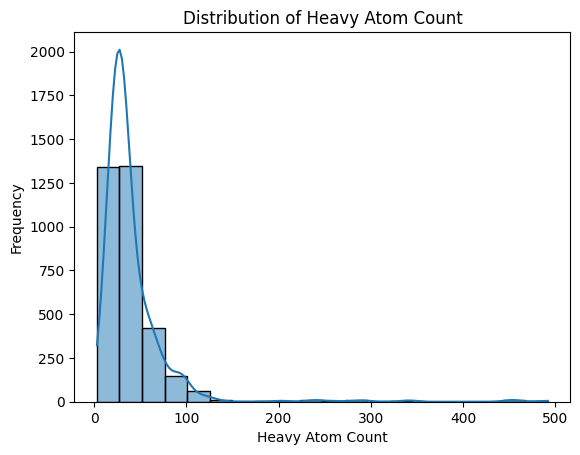

In [49]:
sns.histplot(data=df_fda, x='heavycnt', bins=20, kde=True)
plt.title('Distribution of Heavy Atom Count')
plt.xlabel('Heavy Atom Count')
plt.ylabel('Frequency')
plt.show()

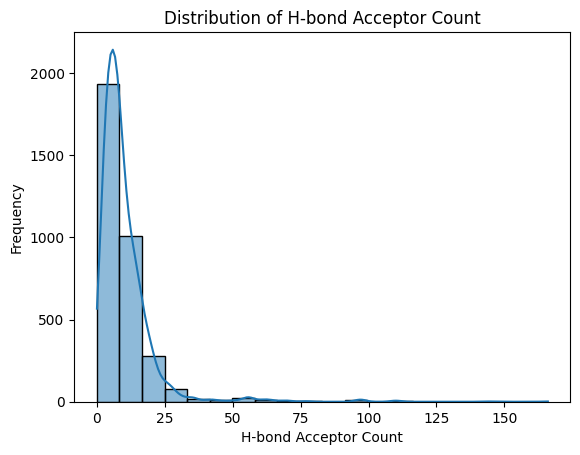

In [50]:
sns.histplot(data=df_fda, x='hbondacc', bins=20, kde=True)
plt.title('Distribution of H-bond Acceptor Count')
plt.xlabel('H-bond Acceptor Count')
plt.ylabel('Frequency')
plt.show()

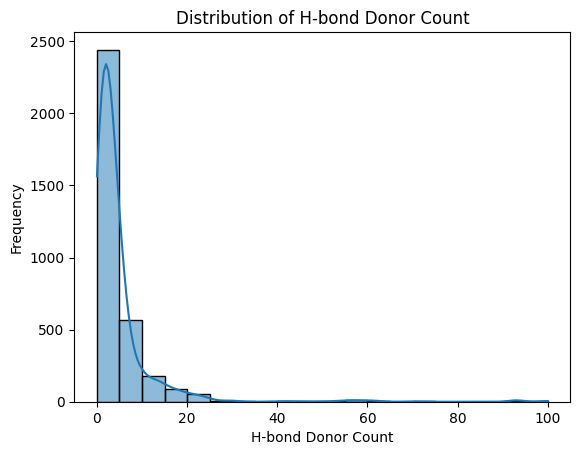

In [51]:
sns.histplot(data=df_fda, x='hbonddonor', bins=20, kde=True)
plt.title('Distribution of H-bond Donor Count')
plt.xlabel('H-bond Donor Count')
plt.ylabel('Frequency')
plt.show()

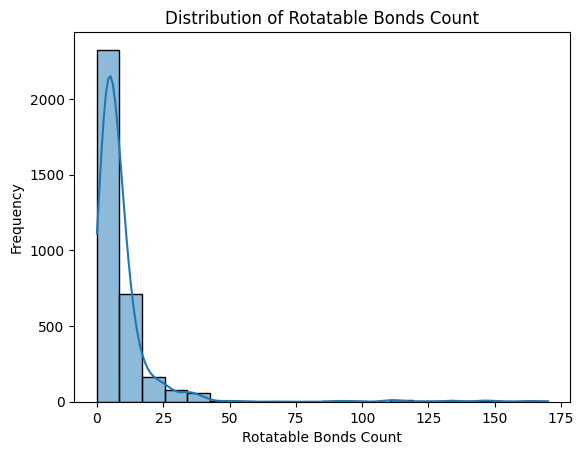

In [52]:
sns.histplot(data=df_fda, bins=20, x='rotbonds', kde=True)
plt.title('Distribution of Rotatable Bonds Count')
plt.xlabel('Rotatable Bonds Count')
plt.ylabel('Frequency')
plt.show()

# III. Looking for similar compounds in the training and fda datasets:

- Comparison of two lists (cid_tg and cid_fda) to find identical molecules:  

In [53]:
#List of cid numbers in the dataframe:
cid_fda = df_fda[' cid']
cid_tg = df_train['cid']

In [54]:

# Find identical elements using set intersection
cross_tg_fda = list(set(cid_tg) & set(cid_fda))

# Display the result
print(f"Identical elements: {cross_tg_fda}")

Identical elements: [4993, 643976, 5578, 135410875, 126941]


# IV. Cleaning FDA database:

-I already removed all inorganics elements (salts, oxides, hydroxides, diatomic molecules)

## 4.1. Drop rows with CID from cross_tg_fda list:

In [55]:
# Filter out rows where 'cid' is in cross_tg_fda
df_fda = df_fda[~df_fda[' cid'].isin(cross_tg_fda)]

# Display the filtered DataFrame
df_fda.shape

(3373, 39)

## 4.2. Salts Removing:

In [56]:
from rdkit import Chem
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit import RDLogger

remover = SaltRemover()  # use default salt remover

# Suppress RDKit warnings
RDLogger.DisableLog('rdApp.*')

# Preprocess the SMILES string by removing SALTS only
def preprocess_smiles(smiles):
    molecule = Chem.MolFromSmiles(smiles)
    
    # If the molecule is None (invalid SMILES), return an empty string
    if molecule is None:
        return ''
    
    # Remove salts
    stripped = remover.StripMol(molecule, dontRemoveEverything=True)
    
    # If the stripped molecule is None or has no atoms, return the original SMILES
    if stripped is None or stripped.GetNumAtoms() == 0:
        return smiles  # Return the original SMILES if nothing remains
    
    # Convert the processed molecule back to SMILES
    preprocessed_smiles = Chem.MolToSmiles(stripped)
    
    return preprocessed_smiles

# Preprocess the SMILES column
df_fda['Clean Smiles'] = df_fda['canonicalsmiles'].apply(preprocess_smiles)

df_fda.to_csv('tmp_df.csv', index=False)

df_fda[['Clean Smiles', 'canonicalsmiles', 'isosmiles']]


,Clean Smiles,canonicalsmiles,isosmiles
0,CC(=O)O,CC(=O)O,CC(=O)O
1,OCc1ccccc1,C1=CC=C(C=C1)CO,C1=CC=C(C=C1)CO
2,C[N+](C)(C)CC(=O)[O-],C[N+](C)(C)CC(=O)[O-],C[N+](C)(C)CC(=O)[O-]
3,O=C=O,C(=O)=O,C(=O)=O
4,O=C(O)CC(O)(CC(=O)O)C(=O)O,C(C(=O)O)C(CC(=O)O)(C(=O)O)O,C(C(=O)O)C(CC(=O)O)(C(=O)O)O
...,...,...,...
3373,COc1ccc2nc(S(=O)Cc3ncc(C)c(OC)c3C)[nH]c2c1.COc...,CC1=CN=C(C(=C1OC)C)CS(=O)C2=NC3=C(N2)C=C(C=C3)...,CC1=CN=C(C(=C1OC)C)C[S@](=O)C2=NC3=C(N2)C=C(C=...
3374,CCC(C)C1OC2(CCC1C)CC1CC(CC=C(C)C(OC3CC(OC)C(OC...,CCC(C)C1C(CCC2(O1)CC3CC(O2)CC=C(C(C(C=CC=C4COC...,CC[C@H](C)[C@@H]1[C@H](CC[C@@]2(O1)C[C@@H]3C[C...
3375,CC(=O)NC(Cc1ccc2ccccc2c1)C(=O)NC(Cc1ccc(Cl)cc1...,CC(C)CC(C(=O)NC(CCCN=C(N)N)C(=O)N1CCCC1C(=O)NC...,C[C@H](C(=O)N)NC(=O)[C@@H]1CCCN1C(=O)[C@H](CCC...
3376,Cc1c(N)nc(C(CC(N)=O)NCC(N)C(N)=O)nc1C(=O)NC(C(...,CC1=C(N=C(N=C1N)C(CC(=O)N)NCC(C(=O)N)N)C(=O)NC...,CC1=C(N=C(N=C1N)[C@H](CC(=O)N)NC[C@H](C(=O)N)N...


## 4.3. Ligand - single molecule only (no complexes)

In [57]:
# Identify rows where the 'smiles' column contains a period, indicating multiple molecules
complex_molecules = df_fda[df_fda['canonicalsmiles'].str.contains('\.')]

# Display the identified complex molecules (optional)
print("Complex molecules identified:")
#print(complex_molecules)
print(len(complex_molecules))

# Filter out rows where the 'smiles' column contains a period
df_fda_filtered = df_fda[~df_fda['canonicalsmiles'].str.contains('\.')]

# Assign the filtered DataFrame back to df_fda
df_fda = df_fda_filtered

# Display the filtered DataFrame
print("Filtered DataFrame:")
df_fda.shape


Complex molecules identified:
1687
Filtered DataFrame:


(1686, 40)

## 4.4. Elements in FDA database:

In [58]:
import re
import pandas as pd

# Regular expression pattern to match atom elements in SMILES
atom_pattern = r'[A-Z][a-z]?'

# Initialize an empty set to hold unique atom elements
atom_elements = set()

# Extract atom elements from each SMILES string
for smiles in df_fda['canonicalsmiles']:
    if smiles:  # Check if the SMILES string is not None
        atoms = re.findall(atom_pattern, smiles)
        atom_elements.update(atoms)

# Convert the set to a list (if needed)
atom_elements_list = list(atom_elements)

# Display the list of atom elements
print("List of atom elements in the dataset:", atom_elements_list)


List of atom elements in the dataset: ['S', 'N', 'O', 'P', 'In', 'I', 'Br', 'Cl', 'F', 'C', 'Se', 'B']


## 4.5. Filtering FDA datbase to keep ligands with atoms presents in the training database:

- ['Br', 'I', 'Cl', 'H', 'O', 'P', 'S', 'F', 'N', 'C'] elements in the Training DB

In [59]:
df_fda.shape

(1686, 40)

In [60]:
# List of elements in the training set
training_elements = ['Br', 'I', 'Cl', 'H', 'O', 'P', 'S', 'F', 'N', 'C']

# Function to check if a SMILES string contains only allowed elements
def contains_only_training_elements(smiles):
    atom_pattern = r'[A-Z][a-z]?'
    atoms = re.findall(atom_pattern, smiles)
    return all(atom in training_elements for atom in atoms)

# Filter the DataFrame
df_fda_filtered = df_fda[df_fda['canonicalsmiles'].apply(contains_only_training_elements)]

# Display the filtered DataFrame
df_fda_filtered.shape


(1678, 40)

In [61]:
# I missed CO2 molecule
# Drop the row where 'cid' equals 280
df_fda_filtered = df_fda_filtered[df_fda_filtered[' cid'] != 280]

# Display the resulting DataFrame
df_fda_filtered.shape


(1677, 40)

In [62]:
# I missed some other inorganic molecules
df_fda_filtered = df_fda_filtered[df_fda_filtered[' cid'] != 948]
df_fda_filtered = df_fda_filtered[df_fda_filtered[' cid'] != 1004]
df_fda_filtered = df_fda_filtered[df_fda_filtered[' cid'] != 163659]

# Display the resulting DataFrame
df_fda_filtered.shape

(1674, 40)

In [63]:
df_fda_filtered.to_csv('PubChem_FDA-approved_Clean.csv', index=False)

In [64]:
df_fda_filtered.shape

(1674, 40)

In [65]:
df_fda_filtered[' cid'].nunique()

1674

In [66]:
df_fda_filtered['Clean Smiles'].nunique()

1096

In [67]:
# Identify duplicates in 'Clean Smiles' column
duplicates = df_fda_filtered[df_fda_filtered.duplicated(subset=['Clean Smiles'], keep=False)]

# Save the duplicates to a new DataFrame
dupl_db = duplicates.copy()

# Optionally, save the duplicates to a CSV file
dupl_db.to_csv('duplicates_fda_database.csv', index=False)

# Display the duplicates
dupl_db.shape


(677, 40)

In [68]:
# Group by 'Clean Smiles' and aggregate the corresponding columns
grouped_df = dupl_db.groupby('Clean Smiles').agg({
    ' cid': list,  # Collect all 'cid' values in the group
    'canonicalsmiles': list,  # Collect all 'canonicalsmiles' values in the group
    'isosmiles': list  # Collect all 'isosmiles' values in the group
}).reset_index()

# Save the grouped data to a new CSV file if needed
grouped_df.to_csv('grouped_fda_database.csv', index=False)

# Display the grouped dataframe
grouped_df[['Clean Smiles', ' cid', 'canonicalsmiles', 'isosmiles']]


,Clean Smiles,cid,canonicalsmiles,isosmiles
0,C#CC1(O)CCC2C3CCC4=CC(=NO)CCC4C3CCC21CC,"[62930, 6537152, 9568628, 13752005, 53461729, ...","[CCC12CCC3C(C1CCC2(C#C)O)CCC4=CC(=NO)CCC34, CC...",[CC[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@]2(C#C)O)CC...
1,C#CC1(O)CCC2C3CCC4=CC(=O)CCC4C3CCC21CC,"[4542, 13109, 5702096, 12598310, 16051930, 601...","[CCC12CCC3C(C1CCC2(C#C)O)CCC4=CC(=O)CCC34, CCC...","[CCC12CCC3C(C1CCC2(C#C)O)CCC4=CC(=O)CCC34, CC[..."
2,C#CC1(OC(C)=O)CCC2C3CCC4=CC(=NO)CCC4C3CCC21CC,"[37083, 89386, 5311328, 5360970, 6324646, 6540...",[CCC12CCC3C(C1CCC2(C#C)OC(=O)C)CCC4=CC(=NO)CCC...,[CC[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@]2(C#C)OC(=...
3,C#CC1(OC(C)=O)CCC2C3CCC4=CC(=O)CCC4C3CCC21C,"[5832, 63021, 541197, 5702094]",[CC(=O)OC1(CCC2C1(CCC3C2CCC4=CC(=O)CCC34)C)C#C...,[CC(=O)O[C@]1(CC[C@@H]2[C@@]1(CC[C@H]3[C@H]2CC...
4,C=C1CCC(O)CC1=CC=C1CCCC2(C)C1CCC2C(C)CCCC(C)C,"[5280795, 117064495]",[CC(C)CCCC(C)C1CCC2C1(CCCC2=CC=C3CC(CCC3=C)O)C...,[C[C@H](CCCC(C)C)[C@H]1CC[C@@H]\2[C@@]1(CCC/C2...
...,...,...,...,...
94,O=C1CN(N=Cc2ccc([N+](=O)[O-])o2)C(=O)N1,"[4509, 5353830, 6604200]","[C1C(=O)NC(=O)N1N=CC2=CC=C(O2)[N+](=O)[O-], C1...","[C1C(=O)NC(=O)N1N=CC2=CC=C(O2)[N+](=O)[O-], C1..."
95,O=C1OCCN1N=Cc1ccc([N+](=O)[O-])o1,"[3435, 5323714, 5353636]","[C1COC(=O)N1N=CC2=CC=C(O2)[N+](=O)[O-], C1COC(...","[C1COC(=O)N1N=CC2=CC=C(O2)[N+](=O)[O-], C1COC(..."
96,OCC(O)C(O)C(O)C(O)CO,"[5780, 6251]","[C(C(C(C(C(CO)O)O)O)O)O, C(C(C(C(C(CO)O)O)O)O)O]","[C([C@H]([C@H]([C@@H]([C@H](CO)O)O)O)O)O, C([C..."
97,OCC1OC(OC2C(CO)OC(O)(CO)C2O)C(O)C(O)C1O,"[11333, 11024312, 16217605, 122173797, 131839611]","[C(C1C(C(C(C(O1)OC2C(OC(C2O)(CO)O)CO)O)O)O)O, ...",[C([C@@H]1[C@@H]([C@@H]([C@H]([C@@H](O1)O[C@@H...


# V. Filtered FDA by MW:

In [69]:
test_mw = df_fda_filtered[(df_fda_filtered['mw'] <= 800)]

test_mw[[' cid','Clean Smiles']].head()

,cid,Clean Smiles
0,176,CC(=O)O
1,244,OCc1ccccc1
2,247,C[N+](C)(C)CC(=O)[O-]
4,311,O=C(O)CC(O)(CC(=O)O)C(=O)O
5,564,NCCCCCC(=O)O


In [70]:
test_mw.shape

(1371, 40)

# VI. Descriptors Calculation:

## 6.1. 1D/2D and FP

In [53]:
unique_smiles = test_mw['Clean Smiles'].unique()

len(unique_smiles)

1013

In [80]:
smiles = unique_smiles[677]
smiles

'COC12CCC3(CC1C(C)(O)C(C)(C)C)C1Cc4ccc(O)c5c4C3(CCN1CC1CC1)C2O5'

In [113]:
# Deelete smiles which give me a problem:
import numpy as np

# Assuming unique_smiles is a NumPy array
unique_smiles = np.delete(unique_smiles, 677)  # Removes the element at index 4562

# Optionally, print the length to verify
print(len(unique_smiles))


1012


In [114]:
%%time
import pandas as pd
from padelpy import padeldescriptor

# Write unique SMILES to a file with SMILES strings as their names
with open('unique_smiles.smi', 'w') as f:
    for smile in unique_smiles:
        f.write(f"{smile} {smile}\n")  # Write SMILES strings as names

# Calculate descriptors using padeldescriptor
padeldescriptor(
    mol_dir='unique_smiles.smi',
    d_file='V2_FDA_2D_descriptors.csv',
    fingerprints=True,
    d_2d=True)

# Read the results from the CSV file and create the DataFrame
df_ligands = pd.read_csv('V2_FDA_2D_descriptors.csv')

# Ensure the first column is SMILES
df_ligands.rename(columns={'Name': 'Clean Smiles'}, inplace=True)

# Save the DataFrame to a new CSV file
df_ligands.to_csv('V2_FDA_2D_descriptors.csv', index=False)

# Display the DataFrame
df_ligands

CPU times: user 1.42 s, sys: 42.5 ms, total: 1.47 s
Wall time: 56.6 s


,Clean Smiles,nAcid,ALogP,ALogp2,AMR,apol,naAromAtom,nAromBond,nAtom,nHeavyAtom,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,CC(=O)O,1,-0.2299,0.052854,12.6437,7.791172,0,0,8,4,...,0,0,0,0,0,0,0,0,0,0
1,OCc1ccccc1,0,-0.4487,0.201332,7.2768,18.456344,6,6,16,8,...,0,0,0,0,0,0,0,0,0,0
2,C[N+](C)(C)CC(=O)[O-],0,-2.2564,5.091341,26.5936,18.838723,0,0,19,8,...,0,0,0,0,0,0,0,0,0,0
3,O=C(O)CC(O)(CC(=O)O)C(=O)O,3,-1.3950,1.946025,35.6239,21.508344,0,0,21,13,...,0,0,0,0,0,0,0,0,0,0
4,NCCCCCC(=O)O,1,-1.8073,3.266333,29.4376,21.932309,0,0,22,9,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,C=CC(=O)N1CCN(c2nc(=O)n(-c3c(C)ccnc3C(C)C)c3nc...,0,1.1012,1.212641,77.8669,83.590583,22,25,72,41,...,0,0,0,0,0,0,0,0,0,0
1008,C=C(F)C(=O)N1CCN(c2nc(OCC3CCCN3C)nc3c2CCN(c2cc...,0,0.4441,0.197225,100.1459,91.698755,16,17,78,43,...,0,0,0,0,0,0,0,0,0,0
1009,CC(O)C1C(=O)N2C(C(=O)[O-])=C(SC3CNC(C(=O)Nc4cc...,0,-4.3654,19.056717,86.5940,65.870239,6,6,56,33,...,0,0,0,0,0,0,0,0,0,0
1010,CC(Cc1ccc(O)c(O)c1)(NN)C(=O)[O-],0,-2.3783,5.656311,31.4449,31.676309,6,6,29,16,...,0,0,0,0,0,0,0,0,0,0


## 6.2. 3D descriptors:

In [116]:
unique_smiles = test_mw['isosmiles'].unique()

len(unique_smiles)

1371

### 6.2.1. GO of structures according SMILES:

In [117]:
from rdkit import Chem
from rdkit.Chem import AllChem

smiles_list = unique_smiles  # Example SMILES
num_conformers = 1  # Number of conformers to generate

# Open the SDF writer
writer = Chem.SDWriter('fda-combined_molecules_test_new_mmff94s.sdf')

# Set ETKDGv3 parameters for conformer generation
etkdg_params = AllChem.ETKDGv3()
etkdg_params.numThreads = 0  # Use all available CPU threads

for smiles in smiles_list:
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:  # Check if molecule conversion is successful
            print(f"Invalid SMILES: {smiles}")
            continue
        
        mol = Chem.AddHs(mol)  # Add hydrogens
        
        # Generate multiple conformers with ETKDGv3
        ids = AllChem.EmbedMultipleConfs(mol, numConfs=num_conformers, params=etkdg_params)
        
        if len(ids) == 0:  # Check if conformer generation is successful
            print(f"Conformer generation failed for molecule: {smiles}")
            continue

        # Optimize each conformer using MMFF94s and get the energy
        energies = []
        for conf_id in ids:
            try:
                # Optimize the molecule using MMFF94s force field
                mmff_props = AllChem.MMFFGetMoleculeProperties(mol, mmffVariant="MMFF94s")
                ff = AllChem.MMFFGetMoleculeForceField(mol, mmff_props, confId=conf_id)
                ff.Minimize()
                
                # Get the energy of the conformer
                energy = ff.CalcEnergy()
                energies.append(energy)
            except Exception as e:
                print(f"Optimization failed for conformer {conf_id} of {smiles}: {e}")
                energies.append(float('inf'))  # Assign a high energy if optimization fails
        
        if all(e == float('inf') for e in energies):  # Check if all optimizations failed
            print(f"All conformer optimizations failed for molecule: {smiles}")
            continue
        
        # Get the conformer with the lowest energy
        min_energy_idx = energies.index(min(energies))
        
        # Create a new molecule with the lowest energy conformer
        lowest_energy_mol = Chem.Mol(mol)
        lowest_energy_mol.RemoveAllConformers()
        lowest_energy_mol.AddConformer(mol.GetConformer(min_energy_idx), assignId=True)
        lowest_energy_mol.SetProp('_Name', smiles)  # Set the name to the SMILES string

        # Write the molecule to the SDF file
        writer.write(lowest_energy_mol)

    except Exception as e:
        print(f"An error occurred for molecule {smiles}: {e}")

# Close the SDF writer
writer.close()

Conformer generation failed for molecule: C[C@@H]1CC[C@H]2[C@H]([C@H](O[C@H]3[C@@]24[C@H]1CC[C@@](O3)(OO4)C)OC(=O)CCC(=O)O)C
Conformer generation failed for molecule: CCCCCCCCCCCCCCCC(=O)OC[C@H](COP(=O)([O-])OCC[N+](C)(C)C)OC(=O)CCCCCCCCCCCCCCC
Conformer generation failed for molecule: CN1[C@H]2CC(C[C@H]1[C@H]3[C@@H]2O3)OC(=O)[C@H](CO)C4=CC=CC=C4
Conformer generation failed for molecule: CCCCCCCCCCC[C@@H](C[C@H]1[C@@H](C(=O)O1)CCCCCC)OC(=O)[C@H](CC(C)C)NC=O
Conformer generation failed for molecule: CC1=C(C(CCC1)(C)C)/C=C/C(=C/C=C/C(=C/C=C/C=C(/C=C/C=C(/C=C/C2=C(CCCC2(C)C)C)\C)\C)/C)/C
Conformer generation failed for molecule: CN1[C@H]2CC(C[C@H]1[C@H]3[C@H]2O3)OC(=O)[C@H](CO)C4=CC=CC=C4
Conformer generation failed for molecule: CCCCCCCCCCCCCC(=O)OC[C@H](COP(=O)([O-])OCC[N+](C)(C)C)OC(=O)CCCCCCCCCCCCC
Conformer generation failed for molecule: CC(C)(C)OC(=O)NCCC(=O)N[C@@H](CC1=CNC2=CC=CC=C21)C(=O)N[C@@H](CCSC)C(=O)N[C@@H](CC(=O)O)C(=O)N[C@@H](CC3=CC=CC=C3)C(=O)N
Conformer generation faile

### 6.2.2. 3D calculation

In [118]:
%%time
from padelpy import padeldescriptor

# Calculate 3D descriptors using padeldescriptor
padeldescriptor(
    mol_dir='fda-combined_molecules_test_new_mmff94s.sdf',
    d_file='V2_FDA_3D_descriptors.csv',
    fingerprints=False,
    d_3d=True,
)

# Read the results from the CSV file and create the DataFrame
df_ligands_3d = pd.read_csv('V2_FDA_3D_descriptors.csv')

# Ensure the first column is SMILES
df_ligands_3d.rename(columns={'Name': 'isosmiles'}, inplace=True)

# Display the DataFrame
df_ligands_3d

CPU times: user 75.3 ms, sys: 17.5 ms, total: 92.8 ms
Wall time: 6.97 s


,isosmiles,TDB1u,TDB2u,TDB3u,TDB4u,TDB5u,TDB6u,TDB7u,TDB8u,TDB9u,...,P1s,P2s,E1s,E2s,E3s,Ts,As,Vs,Ks,Ds
0,CC(=O)O,1.188086,2.059326,2.846971,3.664875,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.675891,0.251010,0.598296,0.586461,0.201286,2.477103,1.456762,4.122364,0.513837,1.386043
1,C1=CC=C(C=C1)CO,1.244260,2.225955,3.056562,3.902539,4.715176,5.312788,5.450515,0.000000,0.000000,...,0.651877,0.286148,0.596945,0.411776,0.213332,5.482172,7.353282,14.740166,0.477816,1.222053
2,C[N+](C)(C)CC(=O)[O-],1.235461,2.136833,2.992280,3.451807,4.181136,0.000000,0.000000,0.000000,0.000000,...,0.498885,0.268948,0.510905,0.494018,0.496925,4.662973,6.793471,14.614774,0.248328,1.501849
3,C(C(=O)O)C(CC(=O)O)(C(=O)O)O,1.253428,2.234601,3.002496,3.700687,4.459732,5.295187,6.515026,7.995231,0.000000,...,0.666386,0.198130,0.434143,0.328064,0.445945,6.885379,11.812247,24.536751,0.499579,1.208152
4,C(CCC(=O)O)CCN,1.220425,2.135392,2.877045,3.599155,4.446809,5.365123,6.537371,7.328814,7.927464,...,0.796821,0.113525,0.607594,0.505312,0.550218,7.942434,10.854883,22.860640,0.695232,1.663124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1351,C[C@@H]1C/C=C/C=C/C=C/C=C/[C@@H](CC2[C@@H]([C@...,1.273147,2.234423,3.017778,3.805330,4.635376,5.418019,6.251687,7.040091,7.775214,...,0.691146,0.264411,0.547051,0.552543,0.428400,35.094317,277.376796,663.516494,0.536718,1.527994
1352,C[C@H]1CC(=CC[C@H]2C[C@H](C[C@@]3(O2)CC(=NOC)[...,1.275367,2.212834,3.080450,3.853493,4.695266,5.394188,6.140234,6.786015,7.362331,...,0.653208,0.261134,0.519468,0.417205,0.467138,28.646117,204.243623,576.353127,0.479812,1.403812
1353,CC[C@@]12CC[C@H]3[C@H]([C@@H]1CC[C@@]2(C#C)O)C...,1.284704,2.251102,3.080775,3.909782,4.701862,5.633798,6.609415,7.480026,8.391247,...,0.727823,0.159858,0.460390,0.488907,0.296570,15.472747,51.724095,115.604732,0.591734,1.245867
1354,[2H]C([2H])([2H])C(=O)N1CCN(CC1)C2=CC=C(C=C2)O...,1.296813,2.249626,3.116833,3.972246,4.720985,5.651647,6.566725,7.563315,8.501780,...,0.896720,0.071627,0.610568,0.343575,0.359560,42.120363,168.330196,362.374177,0.845080,1.313703


In [119]:
# Add prefix to column names
df_ligands_3d = df_ligands_3d.add_prefix('3d-')

# Rename the column
df_ligands_3d.rename(columns={'3d-isosmiles': 'isosmiles'}, inplace=True)

# Display the modified DataFrame
df_ligands_3d.head()

,isosmiles,3d-TDB1u,3d-TDB2u,3d-TDB3u,3d-TDB4u,3d-TDB5u,3d-TDB6u,3d-TDB7u,3d-TDB8u,3d-TDB9u,...,3d-P1s,3d-P2s,3d-E1s,3d-E2s,3d-E3s,3d-Ts,3d-As,3d-Vs,3d-Ks,3d-Ds
0,CC(=O)O,1.188086,2.059326,2.846971,3.664875,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.675891,0.251010,0.598296,0.586461,0.201286,2.477103,1.456762,4.122364,0.513837,1.386043
1,C1=CC=C(C=C1)CO,1.244260,2.225955,3.056562,3.902539,4.715176,5.312788,5.450515,0.000000,0.000000,...,0.651877,0.286148,0.596945,0.411776,0.213332,5.482172,7.353282,14.740166,0.477816,1.222053
2,C[N+](C)(C)CC(=O)[O-],1.235461,2.136833,2.992280,3.451807,4.181136,0.000000,0.000000,0.000000,0.000000,...,0.498885,0.268948,0.510905,0.494018,0.496925,4.662973,6.793471,14.614774,0.248328,1.501849
3,C(C(=O)O)C(CC(=O)O)(C(=O)O)O,1.253428,2.234601,3.002496,3.700687,4.459732,5.295187,6.515026,7.995231,0.000000,...,0.666386,0.198130,0.434143,0.328064,0.445945,6.885379,11.812247,24.536751,0.499579,1.208152
4,C(CCC(=O)O)CCN,1.220425,2.135392,2.877045,3.599155,4.446809,5.365123,6.537371,7.328814,7.927464,...,0.796821,0.113525,0.607594,0.505312,0.550218,7.942434,10.854883,22.860640,0.695232,1.663124


In [122]:
df_ligands_3d.shape

(1356, 432)

# VII. FDA database to work with 

In [71]:
df_ligands = pd.read_csv('V2_FDA_2D_descriptors.csv')
df_ligands_3d = pd.read_csv('V2_FDA_3D_descriptors.csv')

In [72]:
# Add prefix to column names
df_ligands_3d = df_ligands_3d.add_prefix('3d-')

# Rename the column
df_ligands_3d.rename(columns={'3d-Name': 'isosmiles'}, inplace=True)

# Display the modified DataFrame
df_ligands_3d.head(2)

,isosmiles,3d-TDB1u,3d-TDB2u,3d-TDB3u,3d-TDB4u,3d-TDB5u,3d-TDB6u,3d-TDB7u,3d-TDB8u,3d-TDB9u,...,3d-P1s,3d-P2s,3d-E1s,3d-E2s,3d-E3s,3d-Ts,3d-As,3d-Vs,3d-Ks,3d-Ds
0,CC(=O)O,1.188086,2.059326,2.846971,3.664875,0.000000,0.000000,0.000000,0.0,0.0,...,0.675891,0.251010,0.598296,0.586461,0.201286,2.477103,1.456762,4.122364,0.513837,1.386043
1,C1=CC=C(C=C1)CO,1.244260,2.225955,3.056562,3.902539,4.715176,5.312788,5.450515,0.0,0.0,...,0.651877,0.286148,0.596945,0.411776,0.213332,5.482172,7.353282,14.740166,0.477816,1.222053


In [73]:
# 1. Merge Dataset and file with ligand descriptor file: 1D,2D

merged_df=pd.DataFrame()

merged_df = test_mw.merge(df_ligands, on='Clean Smiles', how='inner')
merged_df.shape

(1370, 2365)

In [74]:
# 2. Add Protein descriptors:
merged_df = merged_df.merge(df_ligands_3d, on='isosmiles', how='inner')
merged_df.shape

(1355, 2796)

In [75]:
merged_df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1355 entries, 0 to 1354
Data columns (total 2796 columns):
 #     Column                  Non-Null Count  Dtype  
---    ------                  --------------  -----  
 0      cid                    1355 non-null   int64  
 1     cmpdname                1355 non-null   object 
 2     cmpdsynonym             1331 non-null   object 
 3     mw                      1355 non-null   float64
 4     mf                      1355 non-null   object 
 5     polararea               1355 non-null   float64
 6     complexity              1355 non-null   float64
 7     xlogp                   1355 non-null   float64
 8     heavycnt                1355 non-null   int64  
 9     hbonddonor              1355 non-null   int64  
 10    hbondacc                1355 non-null   int64  
 11    rotbonds                1355 non-null   int64  
 12    inchi                   1355 non-null   object 
 13    isosmiles               1355 non-null   object 
 14    cano

In [76]:
merged_df.to_csv('V2-FDA-merged_df_2d-fp-3d.csv',index=False)

In [77]:
merged_df.rename(columns={' cid': 'cid'}, inplace=True)

# VIII. Model to search outliers in Trainingset

## 7.1. Importance of the Descriptors to use from NN-model

In [78]:
df_imp = pd.read_csv('V2-feature_importance_model_PermImp.csv')
df_imp.head(2)

,Feature,Importance
0,PubchemFP461,0.009318
1,PubchemFP755,0.006300


In [79]:
df_imp.shape

(1858, 2)

In [80]:
df_imp_pos = df_imp[df_imp['Importance']>0]
df_imp_pos.shape[0]

1030

In [81]:
df_imp_pos['Importance'].min()

1.0001948053228738e-06

In [82]:
df_imp_pos['Importance'].max()

0.0093179311212038

In [83]:
features_all_pos = df_imp_pos['Feature'].to_list()

In [84]:
len(features_all_pos)

1030

## 7.2. Feature Engineering

In [85]:
# FDA database with descriptors

merged_df = pd.read_csv('V2-FDA-merged_df_2d-fp-3d.csv')

merged_df.rename(columns={' cid': 'cid'}, inplace=True)

merged_df.head(2)

,cid,cmpdname,cmpdsynonym,mw,mf,polararea,complexity,xlogp,heavycnt,hbonddonor,...,3d-P1s,3d-P2s,3d-E1s,3d-E2s,3d-E3s,3d-Ts,3d-As,3d-Vs,3d-Ks,3d-Ds
0,176,Acetic Acid,acetic acid|ethanoic acid|64-19-7|Acetic acid ...,60.05,C2H4O2,37.3,31.0,-0.2,4,1,...,0.675891,0.251010,0.598296,0.586461,0.201286,2.477103,1.456762,4.122364,0.513837,1.386043
1,244,Benzyl Alcohol,benzyl alcohol|phenylmethanol|benzenemethanol|...,108.14,C7H8O,20.2,55.4,1.1,8,1,...,0.651877,0.286148,0.596945,0.411776,0.213332,5.482172,7.353282,14.740166,0.477816,1.222053


In [86]:
# Reset Indexes:

cols = features_all_pos + ['cid']

df_train = df_train[cols]
df_fda = merged_df[cols]

df_train = df_train.dropna()
df_fda = df_fda.dropna()

df_train = df_train.reset_index(drop=True)
df_fda = df_fda.reset_index(drop=True)

In [87]:
# FOR MODEL
import numpy as np

columns_to_drop = ['cid']

X_train = df_train.drop(columns = columns_to_drop)
y_train = df_train[['cid']]

X_fda = df_fda.drop(columns = columns_to_drop)
y_fda = df_fda[['cid']]

# Replace inf and -inf with NaN, then fill NaN values (or drop rows)
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_fda.replace([np.inf, -np.inf], np.nan, inplace=True)


## 9.2. Missing Data Imputation

In [88]:
# Initialize the imputer with median imputation method
imputer = MeanMedianImputer(imputation_method='median')

# Fit the imputer to the training data
imputer.fit(X_train)

# Transform the training data
X_train_fe = imputer.transform(X_train)
X_fda_fe = imputer.transform(X_fda)


In [89]:
import numpy as np

# Check for NaN values in X_train_fe
has_nan = X_train_fe.isna().sum().sum() > 0

# Check for Infinite values in X_train_fe
has_inf = np.isinf(X_train_fe.values).sum() > 0

# Display the results
print(f"X_train_fe contains NaN values: {has_nan}")
print(f"X_train_fe contains Infinite values: {has_inf}")

X_train_fe contains NaN values: False
X_train_fe contains Infinite values: False


## 9.3. Outliers

In [90]:
%time

# Initialize Winsorizer transformer
winsorizer = Winsorizer(capping_method='gaussian', tail='both')

# Fit and transform on training data
winsorizer.fit(X_train_fe)

X_train_fe = winsorizer.transform(X_train_fe)
X_fda_fe = winsorizer.transform(X_fda_fe)


CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 6.2 µs


In [91]:
import numpy as np

# Check for NaN values in X_train_fe
has_nan = X_train_fe.isna().sum().sum() > 0

# Check for Infinite values in X_train_fe
has_inf = np.isinf(X_train_fe.values).sum() > 0

# Display the results
print(f"X_train_fe contains NaN values: {has_nan}")
print(f"X_train_fe contains Infinite values: {has_inf}")

X_train_fe contains NaN values: False
X_train_fe contains Infinite values: False


## 9.4. YeoJohnsonTransformer:

In [92]:
%time

from feature_engine.transformation import YeoJohnsonTransformer

#Randomly sample 3736 rows from df_t25
yeo_trans = YeoJohnsonTransformer()
yeo_trans.fit(X_train_fe)

X_train_fe = yeo_trans.transform(X_train_fe)
X_fda_fe = yeo_trans.transform(X_fda_fe)


CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 5.96 µs


In [93]:
import numpy as np

# Check for NaN values in X_train_fe
has_nan = X_train_fe.isna().sum().sum() > 0

# Check for Infinite values in X_train_fe
has_inf = np.isinf(X_train_fe.values).sum() > 0

# Display the results
print(f"X_train_fe contains NaN values: {has_nan}")
print(f"X_train_fe contains Infinite values: {has_inf}")

X_train_fe contains NaN values: False
X_train_fe contains Infinite values: False


## 9.5. Scaling:

In [94]:
%time

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Instantiate the StandardScaler
scaler = StandardScaler()

# Fit and transform on the training data
scaler.fit(X_train_fe)

# Scale the training data
X_train_fe_eda = scaler.transform(X_train_fe)
X_fda_fe_eda = scaler.transform(X_fda_fe)

# Convert the numpy arrays back to DataFrames and assign column names
X_train_fe = pd.DataFrame(X_train_fe_eda, columns=X_train.columns)
X_fda_fe = pd.DataFrame(X_fda_fe_eda, columns=X_fda.columns)


CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 6.2 µs


In [95]:
import numpy as np

# Check for NaN values in X_train_fe
has_nan = X_train_fe.isna().sum().sum() > 0

# Check for Infinite values in X_train_fe
has_inf = np.isinf(X_train_fe.values).sum() > 0

# Display the results
print(f"X_train_fe contains NaN values: {has_nan}")
print(f"X_train_fe contains Infinite values: {has_inf}")

X_train_fe contains NaN values: False
X_train_fe contains Infinite values: False


## 7.7. Train the Isolation Forest model on df_train

In [96]:
from sklearn.ensemble import IsolationForest
import pandas as pd

# Step 1: Train the Isolation Forest model on df_train
# Initialize the Isolation Forest model
iso_forest = IsolationForest(contamination=0.05, random_state=42)  # Adjust contamination according to your dataset

# Fit the model to df_train (assuming numerical columns are already selected)
iso_forest.fit(X_train_fe)

# Predict outliers in df_train
X_train['outlier'] = iso_forest.predict(X_train_fe)

# Step 2: Apply the model to df_fda
X_fda['outlier'] = iso_forest.predict(X_fda_fe)

X_fda['cid'] = y_fda

# Outliers are labeled as -1, inliers as 1
outliers_in_fda = X_fda[X_fda['outlier'] == -1]

# Display the outliers detected in df_fda
print("Outliers in df_fda:")
outliers_in_fda.shape


Outliers in df_fda:


(1160, 1032)

In [97]:
in_fda = X_fda[X_fda['outlier'] == 1]
in_fda.shape

(193, 1032)

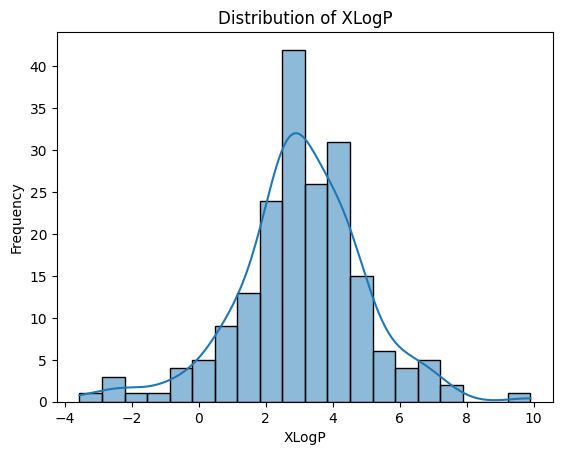

In [98]:
sns.histplot(data=in_fda, x='XLogP', bins=20, kde=True)
plt.title('Distribution of XLogP')
plt.xlabel('XLogP')
plt.ylabel('Frequency')
plt.show()

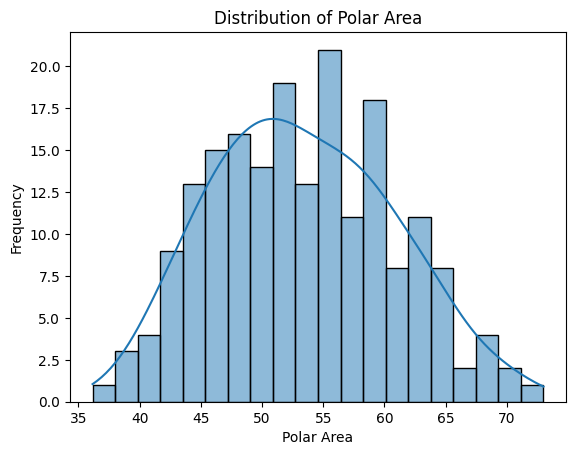

In [99]:
sns.histplot(data=in_fda, x='apol', bins=20, kde=True)
plt.title('Distribution of Polar Area')
plt.xlabel('Polar Area')
plt.ylabel('Frequency')
plt.show()

In [101]:
in_fda.to_csv('fda_to_check.csv', index=False)